In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from src.eigensolvers import francis_double_shift_qr
from src.utils import make_spd_matrix, make_nonsymmetric_matrix, relative_residual, schur_eigs_real
from src.krylov_algorithms import arnoldi, lanczos, conjugate_gradient, gmres

## Arnoldi iteration for general matrices

We work with the Arnoldi process which builds an orthonormal basis of the Krylov space

$$
\mathcal{K}_k(A,b) = \mathrm{span}\{b, Ab, \dots, A^{k-1}b\}
$$

and produces the Arnoldi relation

$$A Q_k = Q_{k+1} \underline{H}_k,$$

where $Q_k$ has orthonormal columns and $\underline{H}_k$ is $(k\!+\!1)\times k$ upper–Hessenberg. In practice, using the Arnoldi iteration gives you a rough idea of the the eigenvalues with less computational cost. This is especially useful for very large matrices. From the initial work of Arnoldi, we can use the eigensolver algorithms from the last homework on the smaller matrices.

We test Arnoldi on a small non-symmetric random matrix, compare the Ritz values (eigenvalues of the projected matrix) with the true eigenvalues of $A$, and experiment with different Krylov dimensions $k$.

max |Ritz_eigensolvers - Ritz_numpy| = 2.048884632553593e-13
max |Ritz_eigensolvers - Ritz_numpy| = 0.00024886295618475884
max |Ritz_eigensolvers - Ritz_numpy| = 1.7976491690072203
max |Ritz_eigensolvers - Ritz_numpy| = 0.005346571462508489


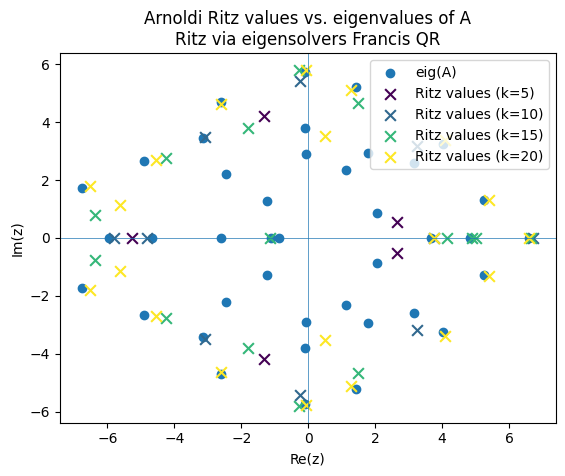

In [3]:
# nonsymmetric matrix
n = 40
A = make_nonsymmetric_matrix(n, seed=1)
b = np.random.default_rng(1).standard_normal(n)

true_vals = np.linalg.eigvals(A)

plt.figure()
plt.scatter(true_vals.real, true_vals.imag, label='eig(A)', marker='o')

k_values = [5, 10, 15, 20]

colors = mpl.colormaps['viridis'](np.linspace(0, 1, len(k_values)))

for idx, k in enumerate(k_values):
    Q, Htilde = arnoldi(A, b, k)

    H = Htilde[:-1, :] 

    fr = francis_double_shift_qr(H, maxit=100)
    H_schur = fr.H
    ritz_vals = schur_eigs_real(H_schur)

    ritz_np = np.linalg.eigvals(H)
    print(f'max |Ritz_eigensolvers - Ritz_numpy| = {np.max(np.abs(np.sort_complex(ritz_vals) - np.sort_complex(ritz_np)))}')

    plt.scatter(
        ritz_vals.real, ritz_vals.imag,
        color=colors[idx],
        marker='x', s=60,
        label=f'Ritz values (k={k})'
    )
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.legend()
plt.title('Arnoldi Ritz values vs. eigenvalues of A\nRitz via eigensolvers Francis QR')
plt.show()


As expected, the Ritz values converge towards the most extreme eigenvalues first and relatively efficiently. The Ritz values tend not to approximate internal eigenvalues with a few exceptions. The right most eigenvalues especially have very good approximations for higher dimension Krylov spaces. Eigenvalues with larger gaps from the nearest other eigenvalue tend to have better approximations. There also appear to be clusters of Ritz values around certain eigenvalues for the same k value, which likely indicates that the Krylov space has a strong component in that eigendirection. Just as all complex eigenvalues come in conjugate pairs which can be seen visually as symmetry across the real axis in the graph, all the Ritz values are also symmetric across the same axis because they are themselves eigenvectors.

## Lanczos iteration for symmetric matrices

We specialize to real symmetric matrices and implement the Lanczos three‑term recurrence. For such matrices the arnoldi hessenberg matrix becomes symmetric tridiagonal.

We run lanczos on a random SPD matrix, compute Ritz values (eigenvalues of $T$), and compare with the true eigenvalues of $A$ for both a well conditioned and ill conditioned $A$.

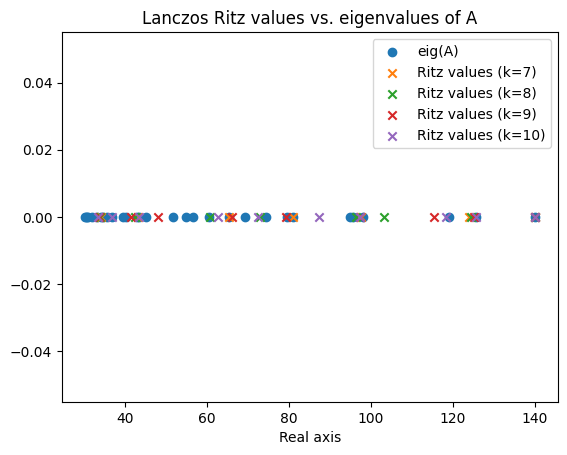

Conditioning number of A: 4.67069428749496


In [ ]:
n = 30
A = make_spd_matrix(n, seed=2)
b = np.random.default_rng(2).standard_normal(n)

kvalues = [7, 8, 9, 10]

true_vals = np.linalg.eigvals(A)

plt.figure()
plt.scatter(true_vals, np.zeros_like(true_vals), label='eig(A)', marker='o')

for i, k in enumerate(kvalues):
    Q, T, alpha, beta = lanczos(A, b, k_max=k)
    ritz_vals = np.linalg.eigvals(T)
    plt.scatter(ritz_vals, np.zeros_like(ritz_vals), label=f'Ritz values (k={k})', marker='x')

plt.xlabel('Real axis')
plt.title('Lanczos Ritz values vs. eigenvalues of A')
plt.legend()
plt.show()

print(f'Conditioning number of A: {np.linalg.cond(A)}')


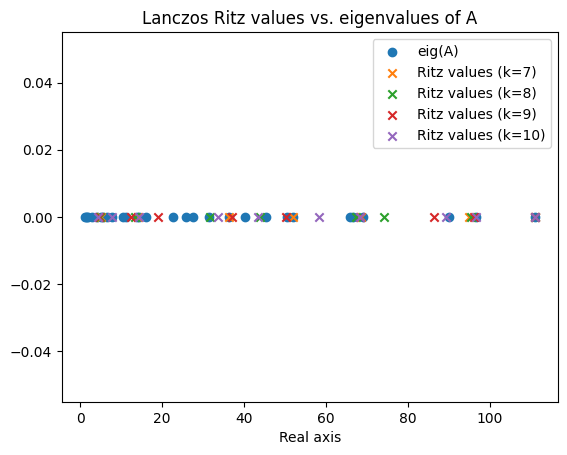

Conditioning number of A: 109.37084468175753


In [ ]:
# make ill conditioned A
n = 30
A = make_spd_matrix(n, shift=1, seed=2)
b = np.random.default_rng(2).standard_normal(n)

true_vals = np.linalg.eigvals(A)

plt.figure()
plt.scatter(true_vals, np.zeros_like(true_vals), label='eig(A)', marker='o')

for i, k in enumerate(kvalues):
    Q, T, alpha, beta = lanczos(A, b, k_max=k)
    ritz_vals = np.linalg.eigvals(T)
    plt.scatter(ritz_vals, np.zeros_like(ritz_vals), label=f'Ritz values (k={k})', marker='x')

plt.xlabel('Real axis')
plt.title('Lanczos Ritz values vs. eigenvalues of A')
plt.legend()
plt.show()

print(f'Conditioning number of A: {np.linalg.cond(A)}')



In both the well conditioned and ill conditioned case, the Ritz values appear to converge to the eigenvalues quickly, with the extreme values (smallest and largest) being approximated extremely well with just the first, smallest krylov space. Convergence for inner eigenvalues is slower but still very consistent as opposed to the relatively erratic behavior of the Arnoldi iteration. Most inner eigenvalues approximated by Ritz values are approximated very well by the largest krylov space. In the ill conditioned case in particular, the Lanczos iteration performs well for the extreme eigenvectors. This is likely because ill conditioning means the spectrum of A is very broad and has large gaps, which is actually beneficial for lanczos iteration because it converges based on the eigengap. However, the smaller eigenvalues are more clustered and thus converge more slowly, meaning the overall performance is not as accurate as the well conditioned matrices

## Conjugate Gradient (CG) for SPD systems

We switch from eigenproblems to linear systems. Recall that conjugate gradient is the Krylov method tailored to symmetric positive definite matrices. It minimizes the $A$ norm of the error over the affine space

$$x_0 + \mathcal{K}_k(A,r_0)$$

We solve $Ax=b$ for a random SPD matrix and plot the residual norm versus iteration on a semilog scale

Conditioning number of A: 4.724432392623587
max iterations to achieve tolerance or reach maxiter 26
Final relative residual: 2.4869943699184693e-14


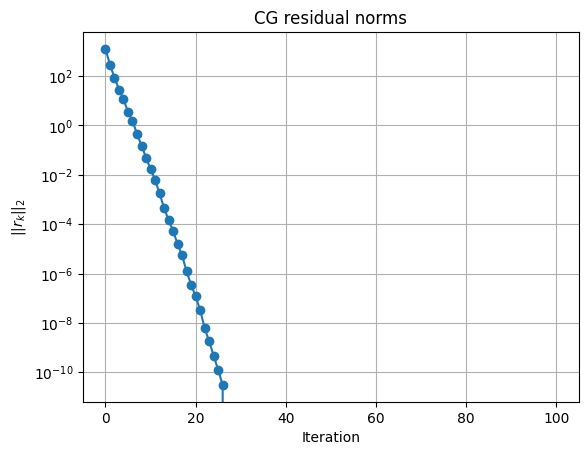

In [7]:
n = 50
A = make_spd_matrix(n, seed=3)
rng = np.random.default_rng(3)
x_true = rng.standard_normal(n)
b = A @ x_true

print(f'Conditioning number of A: {np.linalg.cond(A)}')

x_cg, res_norms, xs = conjugate_gradient(A, b, tol=1e-10, maxiter=100)

print('Final relative residual:', relative_residual(A, x_cg, b))

plt.figure()
plt.semilogy(res_norms, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'$||r_k||_2$')
plt.title('CG residual norms')
plt.grid(True, which='both')
plt.show()

Conditioning number of A: 1.9314848898658974
max iterations to achieve tolerance or reach maxiter 16
Final relative residual: 2.880984018144689e-14


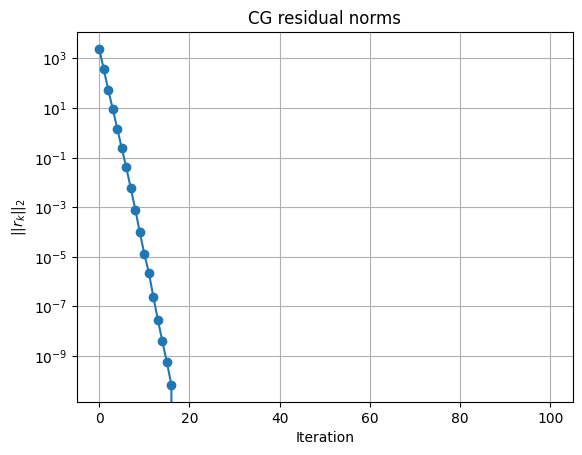

In [8]:
# better conditioned A
n = 50
A = make_spd_matrix(n, seed=3, shift = 200)
rng = np.random.default_rng(3)
x_true = rng.standard_normal(n)
b = A @ x_true

print(f'Conditioning number of A: {np.linalg.cond(A)}')

x_cg, res_norms, xs = conjugate_gradient(A, b, tol=1e-10, maxiter=100)

print('Final relative residual:', relative_residual(A, x_cg, b))

plt.figure()
plt.semilogy(res_norms, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'$||r_k||_2$')
plt.title('CG residual norms')
plt.grid(True, which='both')
plt.show()

Conditioning number of A: 6659.724096142509
max iterations to achieve tolerance or reach maxiter 74
Final relative residual: 1.0719651361374722e-13


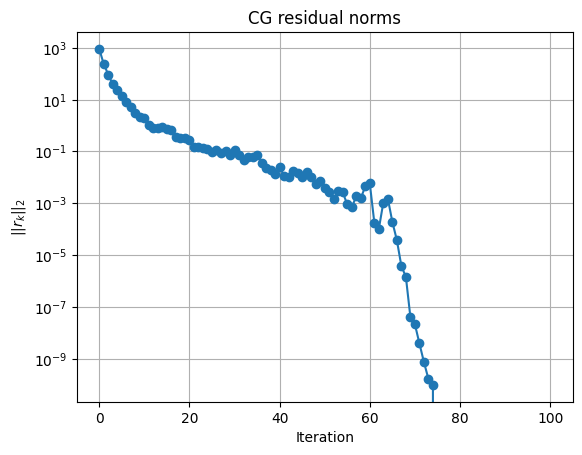

In [9]:
# worse conditioned A
n = 50
A = make_spd_matrix(n, seed=3, shift=.001)
rng = np.random.default_rng(3)
x_true = rng.standard_normal(n)
b = A @ x_true

print(f'Conditioning number of A: {np.linalg.cond(A)}')

x_cg, res_norms, xs = conjugate_gradient(A, b, tol=1e-10, maxiter=100)

print('Final relative residual:', relative_residual(A, x_cg, b))

plt.figure()
plt.semilogy(res_norms, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'$||r_k||_2$')
plt.title('CG residual norms')
plt.grid(True, which='both')
plt.show()

We compare theoretical bound on the number of iterations $n = O(\sqrt{\kappa} \log\left(\frac{1}{\epsilon}\right))$ with actual convergence.

The first test with a conditioning number of about 4.7, the number of expected iterations is about 50, which is larger than the actual number of iterations 26 that it took to meet the tolerance. The same can be said of the second test with the very well conditioned matrix with conditioning number 1.93 that predicts 32 iterations and actually converges in 16. These results follow the theory which predicts a worse case number of iterations.

The ill conditioned matrix is a more interesting example because the number of iterations exceeds the size of the matrix which in exact arithmetic should be impossible since when the number of iterations equals the dimension of the matrix, the Krylov subspace is the entire space. But because A is so poorly conditioned ($\kappa \approx 6659$) iterations over the size of the matrix is not unexpected. Conjugate gradient performs better when the eigenvalues are tightly clustered and worse when they are far apart, which is exactly the case for the final test A. As a result, the roundoff likely destroys orthogonality and causes the Krylov subspace to lose linear independence, resulting in more steps than the dimension of the space.

## Generalized Minimal Residual Method (GMRES)

GMRES is one of the most important Krylov–subspace methods for solving general, non-symmetric linear systems $A x = b,$ when $A$ is not a symmetric positive definite matrix (so CG methods don't apply).  

GMRES is a projection method. After $k$ steps it looks for an approximation of the form

$$ x_k = x_0 + y_k, \quad y_k \in \mathcal{K}_k(A, r_0)$$

where the $k$-dimensional Krylov subspace is 

$$\mathcal{K}_k(A, r_0) = \text{span}\{ r_0, A r_0, A^2 r_0, \dotsc, A^k r_0\} $$

and $r_0 = b - A x_0$ the initial residual.

We solve $Ax=b$ for a random non-symmetric matrix and plot the residual norm versus iteration on a semilog scale

Conditioning number of A: 291.63431662647963
Final relative residual (GMRES) for : 0.17440778210797755
Final relative residual (GMRES) for : 0.30033883162829805
Final relative residual (GMRES) for : 0.37352257498773966
Final relative residual (GMRES) for : 0.6228058761619384


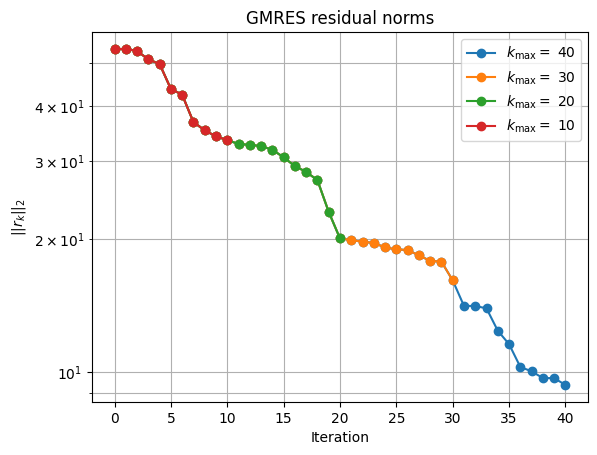

In [ ]:
# normal A
n = 50
A = make_nonsymmetric_matrix(n, seed=10)
rng = np.random.default_rng(4)
x_true = rng.standard_normal(n)
b = A @ x_true

k_values = [40, 30, 20, 10]

print(f'Conditioning number of A: {np.linalg.cond(A)}')

plt.figure()

for k in k_values:
    x_gmres, res_gmres = gmres(A, b, tol=1e-5, k_max=k)

    print('Final relative residual', relative_residual(A, x_gmres, b))
    plt.semilogy(res_gmres, marker='o',label=rf'$k_{{\max}} =$ {k}')

plt.xlabel('Iteration')
plt.ylabel(r'$||r_k||_2$')
plt.title('GMRES residual norms')
plt.grid(True, which='both')
plt.legend()
plt.show()


Conditioning number of A: 19916.944863405017
Final relative residual 3.224689353267967e-05
Final relative residual 9.234678306904678e-05
Final relative residual 0.0002834333576427121
Final relative residual 0.0012376087073538737


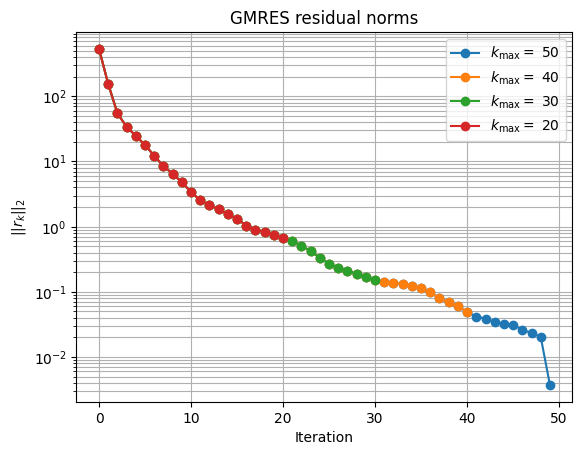

In [11]:
# worse conditioned A
n = 50
A = make_spd_matrix(n, shift=.001)
rng = np.random.default_rng(4)
x_true = rng.standard_normal(n)
b = A @ x_true

k_values = [50, 40, 30, 20]

print(f'Conditioning number of A: {np.linalg.cond(A)}')

plt.figure()

for k in k_values:
    x_gmres, res_gmres = gmres(A, b, tol=1e-5, k_max=k)

    print('Final relative residual', relative_residual(A, x_gmres, b))
    plt.semilogy(res_gmres, marker='o',label=rf'$k_{{\max}} =$ {k}')

plt.xlabel('Iteration')
plt.ylabel(r'$||r_k||_2$')
plt.title('GMRES residual norms')
plt.grid(True, which='both')
plt.legend()
plt.show()

Conditioning number of A: 2.7532502076369827
Final relative residual 2.21083209877189e-09
Final relative residual 2.21083209877189e-09
Final relative residual 8.281913623285318e-07
Final relative residual 0.0010649673224263465


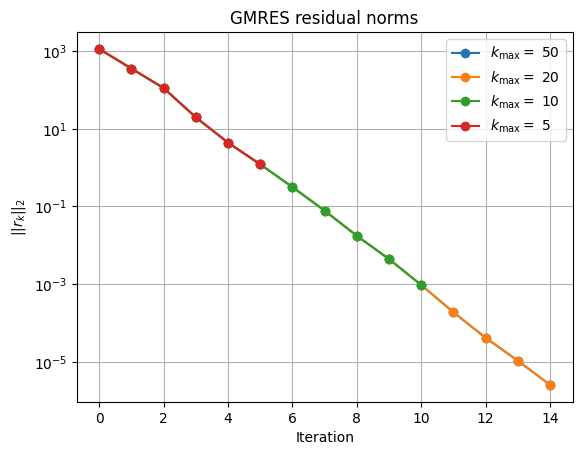

In [12]:
# better conditioned A
n = 50
A = make_spd_matrix(n, shift=100)
rng = np.random.default_rng(4)
x_true = rng.standard_normal(n)
b = A @ x_true

k_values = [50, 20, 10, 5]

print(f'Conditioning number of A: {np.linalg.cond(A)}')

plt.figure()

for k in k_values:
    x_gmres, res_gmres = gmres(A, b, tol=1e-5, k_max=k)

    print('Final relative residual', relative_residual(A, x_gmres, b))
    plt.semilogy(res_gmres, marker='o',label=rf'$k_{{\max}} =$ {k}')

plt.xlabel('Iteration')
plt.ylabel(r'$||r_k||_2$')
plt.title('GMRES residual norms')
plt.grid(True, which='both')
plt.legend()
plt.show()

As expected, GMRES performs better on more well conditioned matrices. On the regular, non-symmetric A GMRES gives a smaller residual for each larger k_max but does not achieve the tolerance even in the largest number of iterations. This follows for all other matrices and makes sense with the theory because making the Krylov dimension larger intuitively gives a smaller residual from the resulting least squares solve. The residual norm seems to scare linearly on a log scale. Also inline, the residual norm is monotonically decreasing as the iterations increase. For the extremely ill conditioned and extremely well conditioned cases, I used the PSD helper function for easy conditioning manipulation. The well conditioned case performed significantly better than the ill conditioned case. The ill conditioned case did not achieve the bound even at 50 iterations, likely deviating from the expected $||r_m|| = 0$ because of rounding errors in the ill conditioned case. The well conditioned case, on the other hand exceeded the tolerance in 14 iterations, less than all $k_{{\max}}$ values testing in the opposite case.